# 02 &mdash; A Priori Forecastability

Before fitting any model, this notebook asks a blunt question:
*how forecastable is this series, in theory?* Three complementary
diagnostics &mdash; spectral predictability, permutation entropy, and the
Hurst exponent with Lo's modified R/S test &mdash; converge on the same
answer: coffee futures are near-random. That prior is what sets up the
benchmark in notebook 01 to be meaningful in the first place.

## Why this notebook exists

If the series had exploitable structure, we'd expect complex models to
beat naive baselines. The a priori metrics let us form an expectation
*before* seeing any forecast results &mdash; which is methodologically
important, because it turns the benchmark from “a fishing expedition”
into a hypothesis test of whether any model can extract what the
diagnostics say isn't there.

## 1. Setup

In [61]:
import sys
from pathlib import Path

# Make the sibling package importable without requiring `pip install -e .`.
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from coffee_forecast import (
    load_coffee_data,
    calculate_spectral_predictability,
    calculate_permutation_entropy,
    calculate_hurst_exponent,
)
from coffee_forecast.config import FIG_DIR

FIG_DIR.mkdir(parents=True, exist_ok=True)

In [62]:
df = load_coffee_data()
prices = df["y"].values.astype(float)
log_returns = np.diff(np.log(prices))

print(
    f"Loaded {len(df)} trading days ({df['ds'].min().date()} → {df['ds'].max().date()})"
)
print(
    f"  prices:      {len(prices)} observations, "
    f"min={prices.min():.1f}, max={prices.max():.1f}"
)
print(
    f"  log-returns: {len(log_returns)} observations, "
    f"mean={log_returns.mean():+.5f}, std={log_returns.std():.4f}"
)

Loaded 8104 trading days (1994-01-03 → 2026-01-30)
  prices:      8104 observations, min=41.5, max=438.9
  log-returns: 8103 observations, mean=+0.00019, std=0.0237


## 2. Stationarity: prices vs. log-returns

Two of the three diagnostics below (spectral predictability, permutation
entropy) run on whatever representation the models will forecast &mdash; raw
prices, in this paper. The third (Hurst) is defined only for stationary
series, so it runs on log-returns. Before doing any of that, we verify
the stationarity claim with an Augmented Dickey-Fuller test.

In [63]:
from statsmodels.tsa.stattools import adfuller

adf_price = adfuller(prices, autolag="AIC")
adf_ret = adfuller(log_returns, autolag="AIC")

print("Augmented Dickey-Fuller Test:")
print(
    f"  Prices      : ADF = {adf_price[0]:+7.3f},  p = {adf_price[1]:6.3f}  "
    f"→ {'Non-stationary' if adf_price[1] > 0.05 else 'Stationary'}"
)
print(
    f"  Log-returns : ADF = {adf_ret[0]:+7.3f},  p = {adf_ret[1]:.2e}  "
    f"→ {'Non-stationary' if adf_ret[1] > 0.05 else 'Stationary'}"
)

Augmented Dickey-Fuller Test:
  Prices      : ADF =  -1.451,  p =  0.557  → Non-stationary
  Log-returns : ADF = -20.879,  p = 0.00e+00  → Stationary


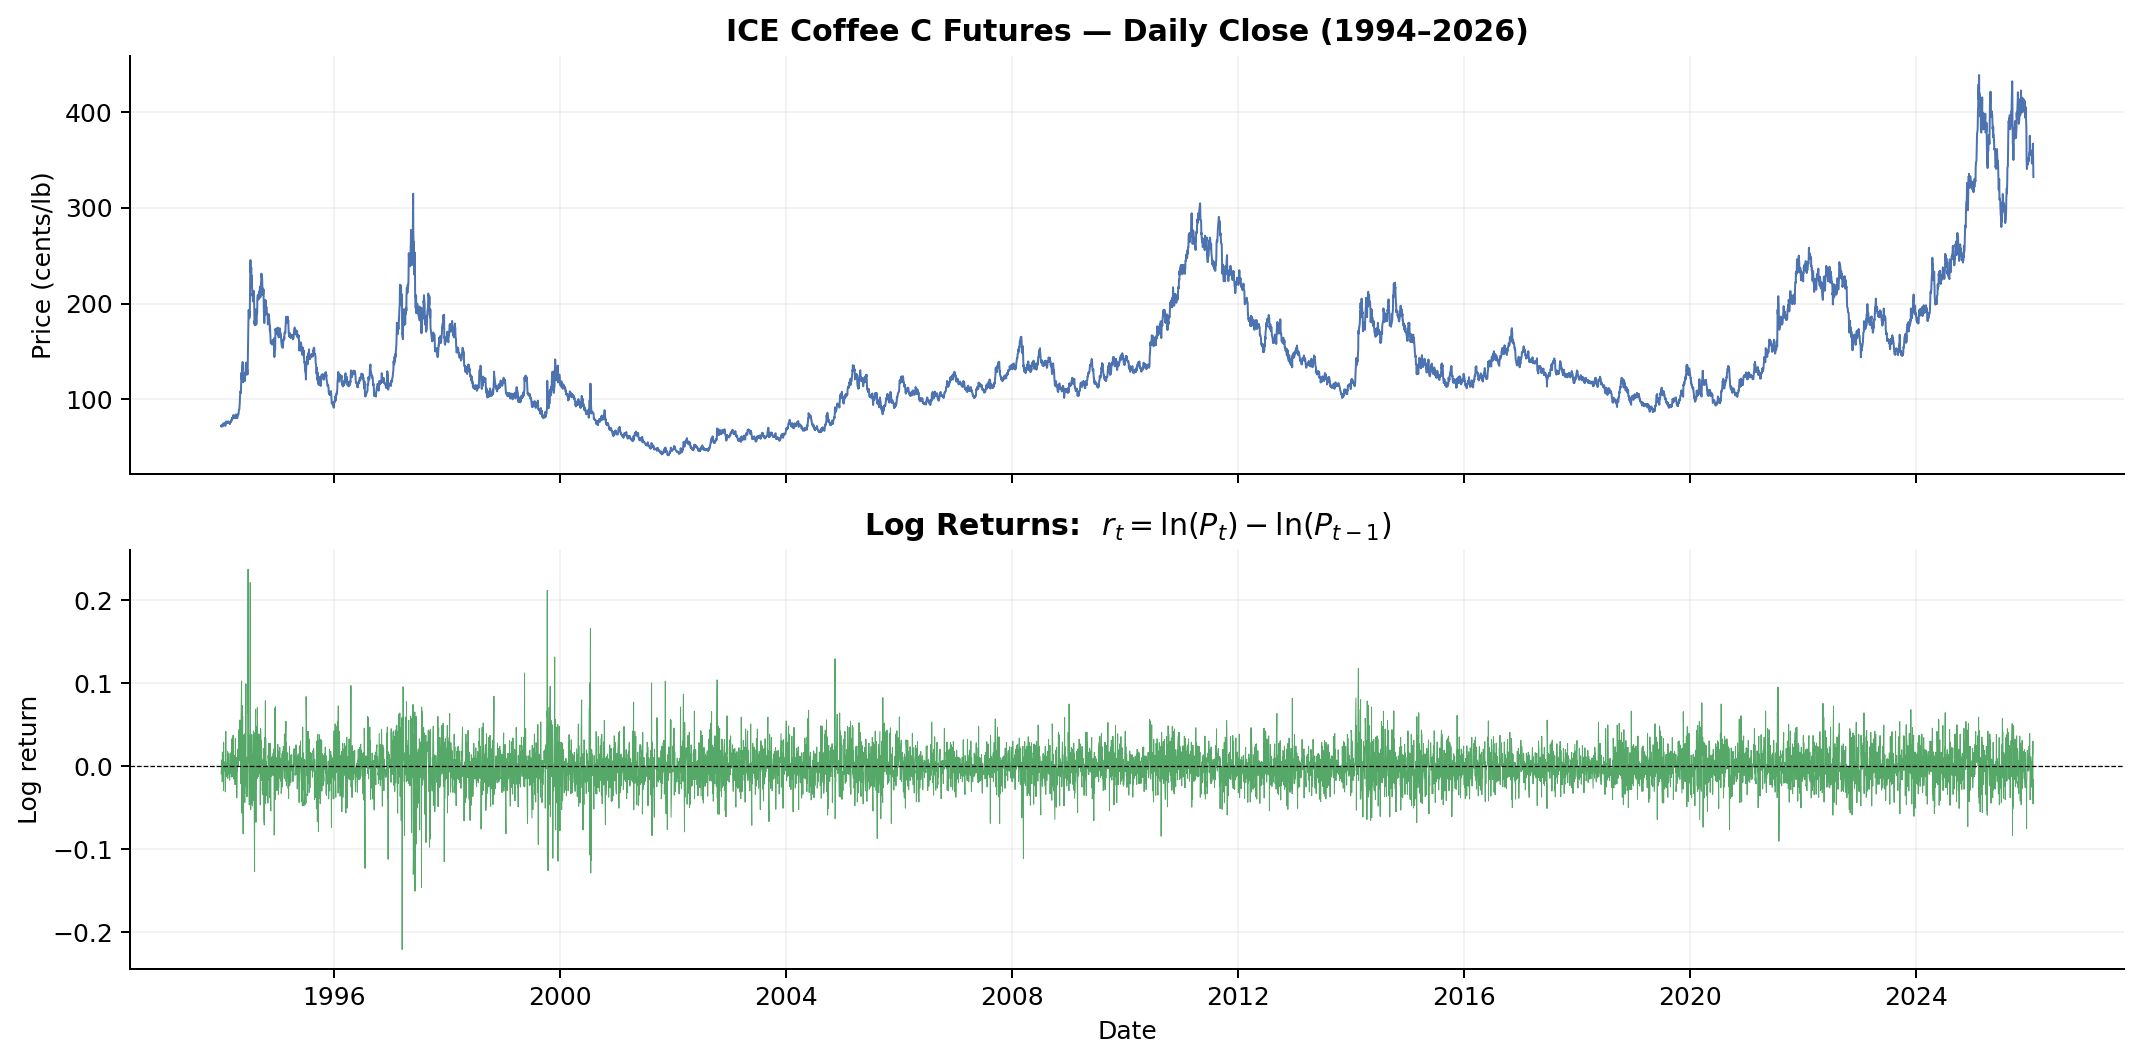

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, dpi=180)

axes[0].plot(df["ds"], prices, linewidth=0.8, color="#4C72B0")
axes[0].set_title(
    "ICE Coffee C Futures \u2014 Daily Close (1994\u20132026)",
    fontsize=12,
    weight="semibold",
)
axes[0].set_ylabel("Price (cents/lb)")
axes[0].grid(alpha=0.15)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(df["ds"].iloc[1:], log_returns, linewidth=0.4, color="#55A868")
axes[1].axhline(0, color="black", lw=0.5, ls="--")
axes[1].set_title(
    r"Log Returns:  $r_t = \ln(P_t) - \ln(P_{t-1})$", fontsize=12, weight="semibold"
)
axes[1].set_ylabel("Log return")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.15)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "prices_vs_logreturns.png", dpi=300, bbox_inches="tight")
plt.show()

The ADF result is exactly what you'd expect of a commodity price:
prices are non-stationary (they wander), log-returns are stationary
(they hover around zero with roughly constant variance &mdash; the
well-known volatility clustering notwithstanding).

## 3. Spectral Predictability ($\Omega$)

Spectral predictability (Wang & Klee, KDD 2025) measures how much
energy is concentrated in a few dominant frequencies. A series with
strong periodic structure has a spiked PSD and a high $\Omega$; white
noise has a flat PSD and $\Omega \to 0$.

$$\Omega = 1 - \frac{H_{\text{spectral}}}{\log(N_{\text{freq}})}$$

**Normalization note.** The original paper normalizes by $\log(2\pi)$
(the continuous-time limit). For long discrete series this produces
$\Omega$ values outside $[0, 1]$ because $\log(N_{\text{freq}})$
dominates. We normalize by $\log(N_{\text{freq}})$ &mdash; the entropy of
discrete white noise of the same length &mdash; which keeps $\Omega$
bounded in $[0, 1]$ and makes the 0.20 forecastability threshold
interpretable at any $T$.

In [65]:
omega = calculate_spectral_predictability(prices)
print(f"Spectral Predictability  Ω = {omega:.4f}")

Spectral Predictability  Ω = 0.6749


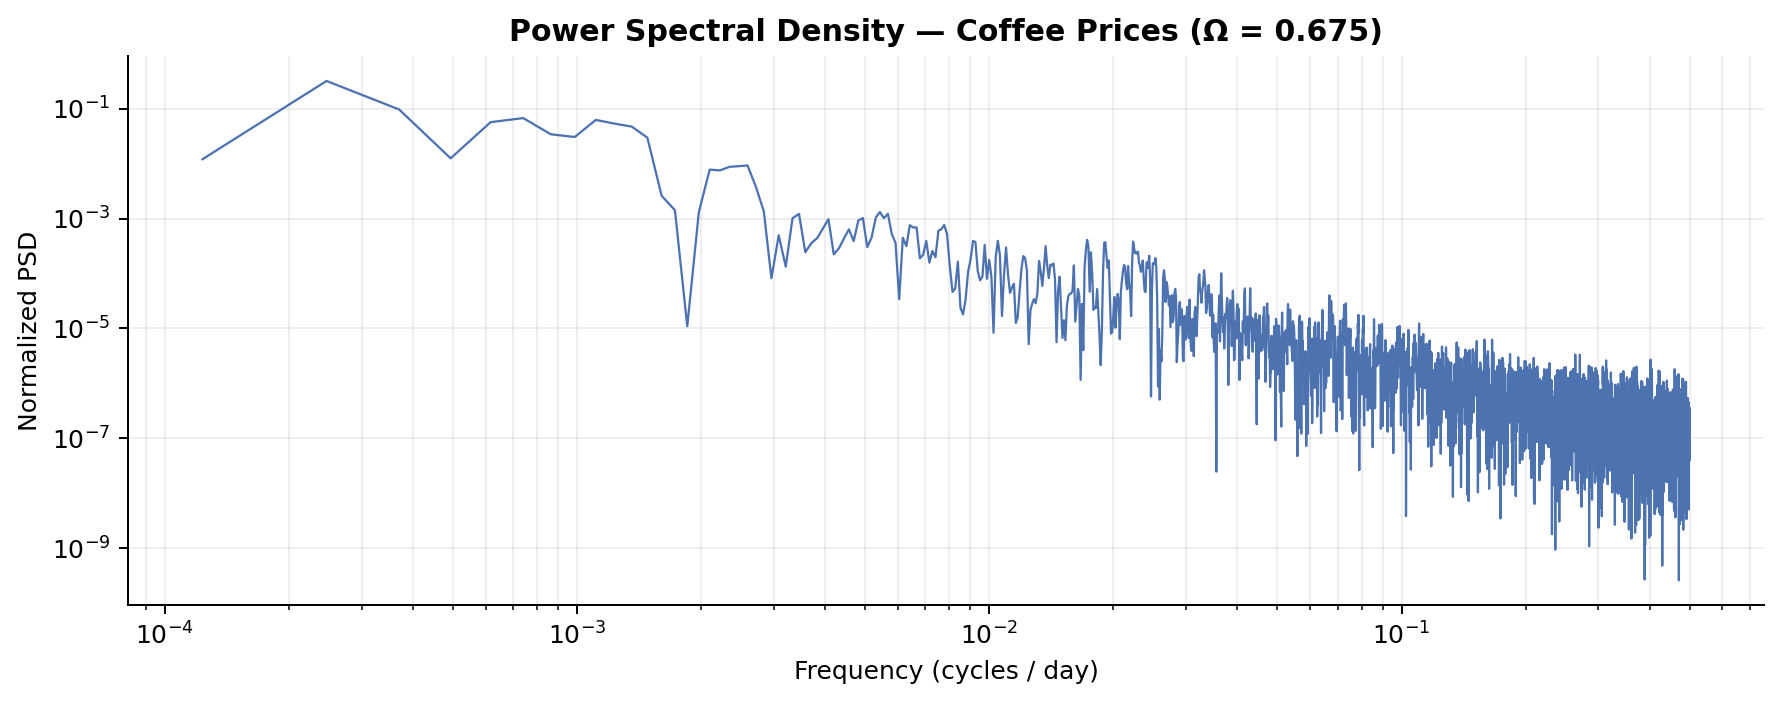

In [66]:
# Replicate the internal PSD computation so we can plot it.
from scipy.signal import detrend

detrended = detrend(prices)
windowed = detrended * np.hanning(len(detrended))
fft_vals = np.fft.rfft(windowed)
psd = np.abs(fft_vals) ** 2
psd_norm = psd / np.sum(psd)
freqs = np.fft.rfftfreq(len(detrended), d=1.0)  # cycles / day

fig, ax = plt.subplots(figsize=(10, 4), dpi=180)
ax.loglog(freqs[1:], psd_norm[1:], color="#4C72B0", linewidth=0.9)
ax.set_title(
    f"Power Spectral Density \u2014 Coffee Prices (\u03a9 = {omega:.3f})",
    fontsize=12,
    weight="semibold",
)
ax.set_xlabel("Frequency (cycles / day)")
ax.set_ylabel("Normalized PSD")
ax.grid(alpha=0.2, which="both")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "spectral_psd.png", dpi=300, bbox_inches="tight")
plt.show()

$\Omega \approx 0.67$ sounds high, but the shape of the PSD tells the
real story: the energy concentrates at the *lowest* frequencies with no
discrete peaks. That's the fingerprint of a non-stationary random walk
(low-frequency drift), not of exploitable periodic structure. In other
words, "structure" exists &mdash; but it's the kind that makes the series
*harder* to forecast, not easier.

## 4. Permutation Entropy (PE)

Permutation entropy measures *ordinal-pattern complexity*. For
embedding order $m = 3$, we slide a window of length 3 across the
series and count the six possible rank orderings. If all six patterns
occur roughly equally often, PE $\to 1$ (maximally random). If a few
dominate, PE $\to 0$ (deterministic structure).

It's a complementary perspective to spectral predictability: the PSD
cares about *periodicities*, while PE cares about *local orderings*.
A series can fool one and not the other, so agreement is meaningful.

In [67]:
pe = calculate_permutation_entropy(prices, order=3, delay=1)
print(f"Permutation Entropy  PE = {pe:.4f}  ({pe * 100:.1f}% stochastic)")

Permutation Entropy  PE = 0.9742  (97.4% stochastic)


97% is near the ceiling &mdash; the six ordinal patterns of length 3 are
almost uniformly distributed in the price series. There's essentially
no deterministic local structure to exploit.

## 5. Hurst exponent + Lo's modified R/S

The Hurst exponent $H$ is estimated from the log-log slope of the
rescaled range $(R/S)_n$ vs. window size $n$:

$$\mathbb{E}[(R/S)_n] \sim c \cdot n^H$$

- $H = 0.5$ : random walk, no exploitable memory
- $H > 0.5$ : persistent / trending
- $H < 0.5$ : anti-persistent / mean-reverting

Classical $H$ is biased upward by short-range autocorrelation, so we
also compute Lo's (1991) modified R/S statistic $V_n$, which uses a
Bartlett-kernel HAC adjustment. Under $H_0$ of no long memory,
$V_n \in [0.809, 1.862]$ at the 95% level.

**Why returns, not prices?** $R/S$ is defined for stationary series.
Computing it on the non-stationary price level would give a misleading
$H \approx 1$ regardless of the underlying dynamics. Log-returns are
the standard, theoretically correct representation.

In [68]:
h, v_n, lo_result = calculate_hurst_exponent(prices)

lo_lower, lo_upper = 0.809, 1.862
verdict = (
    f"FAIL TO REJECT H0 (V_n = {v_n:.3f} inside [{lo_lower}, {lo_upper}])\n"
    f"  → No statistically significant long memory at 95%; "
    f"H ≈ 0.5 likely reflects short-range autocorrelation bias"
    if lo_result == "fail to reject"
    else f"REJECT H0 (V_n = {v_n:.3f} outside [{lo_lower}, {lo_upper}])\n"
    f"  → Statistically significant long memory detected"
)

print(f"Hurst exponent  H   = {h:.4f}")
print(f"Lo's V_n            = {v_n:.4f}")
print(f"  {verdict}")

Hurst exponent  H   = 0.5353
Lo's V_n            = 1.1374
  FAIL TO REJECT H0 (V_n = 1.137 inside [0.809, 1.862])
  → No statistically significant long memory at 95%; H ≈ 0.5 likely reflects short-range autocorrelation bias


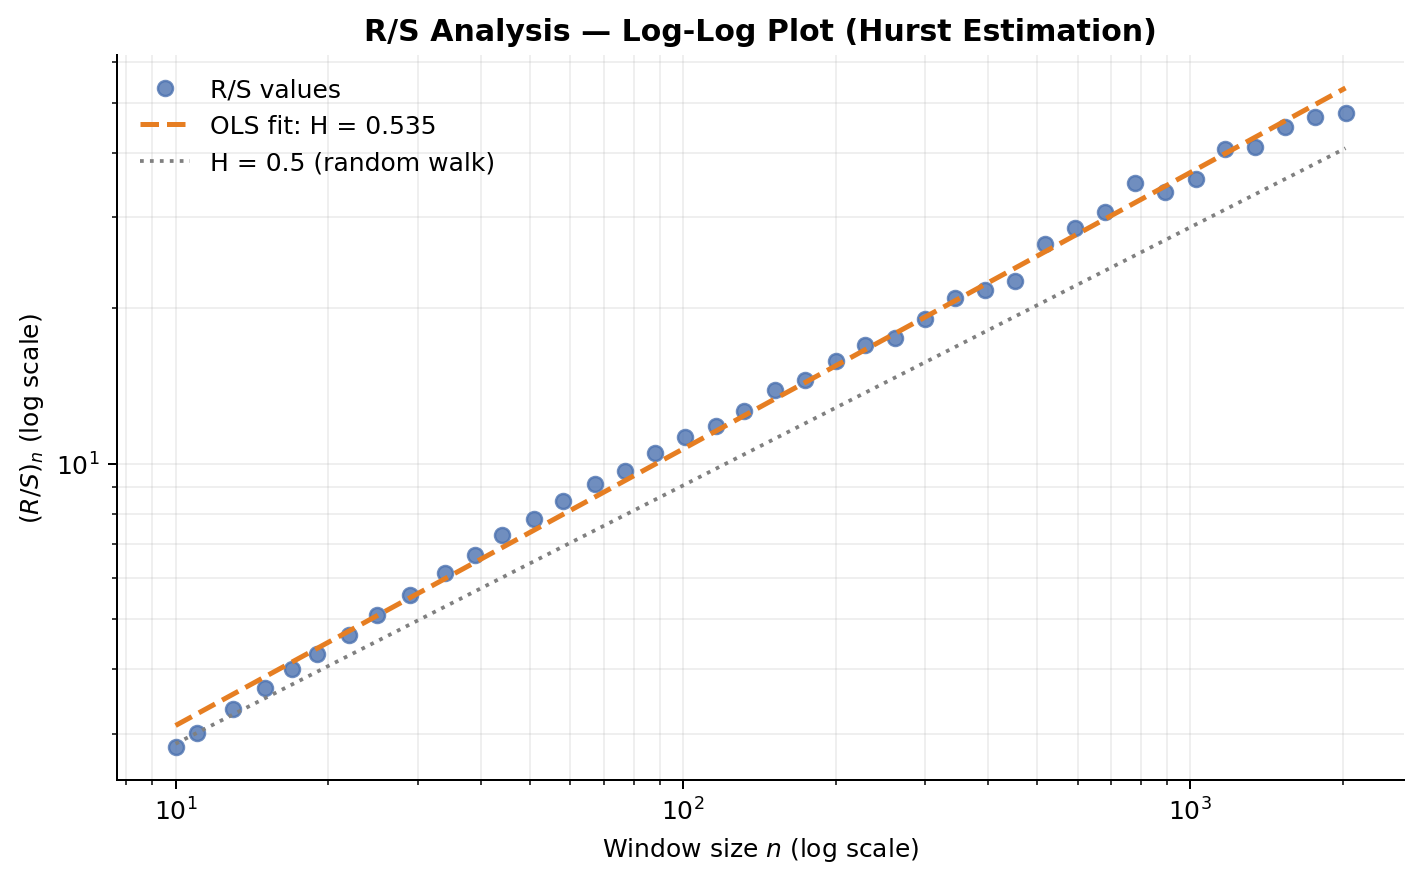

In [69]:
# Reproduce the R/S log-log plot used to estimate H.
from scipy import stats as sp_stats

rets = log_returns
T = len(rets)
n_max = T // 4
window_sizes = np.unique(np.logspace(np.log10(10), np.log10(n_max), 40).astype(int))


def _rs(x, n):
    num = len(x) // n
    if num == 0:
        return np.nan
    vals = []
    for w in range(num):
        chunk = x[w * n : (w + 1) * n]
        e = chunk - chunk.mean()
        X = np.cumsum(e)
        R = X.max() - X.min()
        S = chunk.std(ddof=1)
        if S > 0:
            vals.append(R / S)
    return np.mean(vals) if vals else np.nan


rs_vals = np.array([_rs(rets, n) for n in window_sizes])
valid = ~np.isnan(rs_vals) & (rs_vals > 0)
slope, intercept, *_ = sp_stats.linregress(
    np.log(window_sizes[valid]), np.log(rs_vals[valid])
)

fig, ax = plt.subplots(figsize=(8, 5), dpi=180)
ax.loglog(
    window_sizes[valid],
    rs_vals[valid],
    "o",
    color="#4C72B0",
    markersize=6,
    alpha=0.8,
    label="R/S values",
)
xs_line = np.array([window_sizes[valid].min(), window_sizes[valid].max()])
ax.plot(
    xs_line,
    np.exp(intercept + slope * np.log(xs_line)),
    "--",
    color="#E67E22",
    linewidth=2,
    label=f"OLS fit: H = {slope:.3f}",
)
ax.plot(
    xs_line,
    np.exp(intercept + 0.5 * np.log(xs_line)),
    ":",
    color="gray",
    linewidth=1.5,
    label="H = 0.5 (random walk)",
)

ax.set_title(
    "R/S Analysis \u2014 Log-Log Plot (Hurst Estimation)",
    fontsize=12,
    weight="semibold",
)
ax.set_xlabel("Window size $n$ (log scale)")
ax.set_ylabel("$(R/S)_n$ (log scale)")
ax.legend(frameon=False, fontsize=10)
ax.grid(alpha=0.2, which="both")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "hurst_rs.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Synthesis

The three diagnostics paint a consistent picture.

In [70]:
import pandas as pd

summary = pd.DataFrame(
    [
        {
            "Metric": "Spectral Predictability (Ω)",
            "Representation": "prices",
            "Value": f"{omega:.4f}",
            "Interpretation": "Energy in low frequencies only; no periodic peaks",
        },
        {
            "Metric": "Permutation Entropy (PE)",
            "Representation": "prices",
            "Value": f"{pe:.4f}",
            "Interpretation": f"{pe * 100:.1f}% stochastic; ordinal patterns near-uniform",
        },
        {
            "Metric": "Hurst exponent (H)",
            "Representation": "log-returns",
            "Value": f"{h:.4f}",
            "Interpretation": "Near 0.5 \u2014 consistent with random walk",
        },
        {
            "Metric": "Lo's modified R/S (V_n)",
            "Representation": "log-returns",
            "Value": f"{v_n:.4f}",
            "Interpretation": f"{lo_result} H0 of no long memory at 95%",
        },
    ]
)
summary

,Metric,Representation,Value,Interpretation
0,Spectral Predictability (Ω),prices,0.6749,Energy in low frequencies only; no periodic peaks
1,Permutation Entropy (PE),prices,0.9742,97.4% stochastic; ordinal patterns near-uniform
2,Hurst exponent (H),log-returns,0.5353,Near 0.5 — consistent with random walk
3,Lo's modified R/S (V_n),log-returns,1.1374,fail to reject H0 of no long memory at 95%


**Conclusion.** Coffee futures exhibit the statistical fingerprint of a
near-random walk: energy concentrated at the lowest frequencies
(drift, not periodicity), ordinal-pattern entropy near its ceiling, and
no statistically significant long memory after correcting for
short-range autocorrelation. The a priori prior is therefore strong:
simple baselines that match this structure (random walk with drift,
naïve, exponential smoothing) should be competitive with arbitrarily
complex models. Notebook 01 tests whether that prior holds up in
practice.

---

**On log-returns.** They appear here only where analytically required
(stationarity for $R/S$). They will reappear in notebook 05 (GJR-GARCH
deployment), where modeling their volatility structure directly is
what produces the paper's prediction intervals.

**Next notebook:** `03_statistical_tests.ipynb` &mdash; Diebold-Mariano
pairwise tests and the Model Confidence Set applied to the per-origin
loss series from notebook 01.